# Notebook 02
# Detección y Tratamiento de Outliers

Proyecto:
Análisis ENAHO 2025

Objetivo:
Detectar valores atípicos mediante métodos estadísticos y generar un nuevo dataset limpio para el análisis posterior.

In [1]:
# ==========================================
# LIBRERÍAS
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [2]:
# ==========================================
# CARGA DEL DATASET
# ==========================================

ruta = "../data/processed/datos_procesados.csv"

df = pd.read_csv(ruta)

print(f"Dimensiones del dataset: {df.shape}")

df.head()

Dimensiones del dataset: (32764, 13)


,PERCEPHO,P103,P104,P105A,EDUCACION_JEFE,DOMINIO,NUM_SERVICIOS,NUM_EQUIPOS,NUM_OCUPADOS,EDAD_JEFE,PCT_NINOS,POBREZA,HACINAMIENTO
0,2,2.0,4.0,2.0,11.0,4,8,6,1.0,45.0,0.000000,3,2.0
1,2,5.0,3.0,2.0,6.0,4,8,6,2.0,42.0,0.333333,3,6.0
2,2,5.0,3.0,2.0,8.0,4,8,6,2.0,44.0,0.333333,3,3.0
3,1,5.0,2.0,2.0,1.0,4,8,6,1.0,78.0,0.000000,3,1.0
4,2,5.0,1.0,1.0,10.0,4,8,6,2.0,33.0,0.333333,3,3.0


In [3]:
# ==========================================
# EXPLORACIÓN INICIAL DEL DATASET
# ==========================================

print("=" * 60)
print("INFORMACIÓN GENERAL")
print("=" * 60)

df.info()

print("\n" + "=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)

display(df.describe())

print("\n" + "=" * 60)
print("VALORES NULOS")
print("=" * 60)

display(df.isnull().sum())

print("\nCantidad total de valores nulos:",
      df.isnull().sum().sum())

INFORMACIÓN GENERAL
<class 'pandas.DataFrame'>
RangeIndex: 32764 entries, 0 to 32763
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PERCEPHO        32764 non-null  int64  
 1   P103            32764 non-null  float64
 2   P104            32764 non-null  float64
 3   P105A           32764 non-null  float64
 4   EDUCACION_JEFE  32764 non-null  float64
 5   DOMINIO         32764 non-null  int64  
 6   NUM_SERVICIOS   32764 non-null  int64  
 7   NUM_EQUIPOS     32764 non-null  int64  
 8   NUM_OCUPADOS    32764 non-null  float64
 9   EDAD_JEFE       32764 non-null  float64
 10  PCT_NINOS       32764 non-null  float64
 11  POBREZA         32764 non-null  int64  
 12  HACINAMIENTO    32764 non-null  float64
dtypes: float64(8), int64(5)
memory usage: 3.2 MB

ESTADÍSTICAS DESCRIPTIVAS


,PERCEPHO,P103,P104,P105A,EDUCACION_JEFE,DOMINIO,NUM_SERVICIOS,NUM_EQUIPOS,NUM_OCUPADOS,EDAD_JEFE,PCT_NINOS,POBREZA,HACINAMIENTO
count,32764.000000,32764.000000,32764.000000,32764.000000,32764.000000,32764.000000,32764.0,32764.0,32764.000000,32764.000000,32764.000000,32764.000000,32764.000000
mean,1.998108,4.683189,3.278293,2.561012,5.549322,4.863234,8.0,6.0,1.665853,54.235075,0.123998,2.782871,2.946040
std,0.996834,1.251797,1.634362,1.490347,2.418221,2.359349,0.0,0.0,1.049892,15.684527,0.178676,0.490776,1.956745
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.0,6.0,0.000000,16.000000,0.000000,1.000000,0.125000
25%,1.000000,4.000000,2.000000,2.000000,4.000000,3.000000,8.0,6.0,1.000000,42.000000,0.000000,3.000000,1.000000
50%,2.000000,5.000000,3.000000,2.000000,6.000000,5.000000,8.0,6.0,2.000000,54.000000,0.000000,3.000000,3.000000
75%,2.000000,6.000000,4.000000,2.000000,7.000000,7.000000,8.0,6.0,2.000000,66.000000,0.250000,3.000000,4.000000
max,9.000000,7.000000,15.000000,7.000000,12.000000,8.000000,8.0,6.0,9.000000,98.000000,0.833333,3.000000,16.000000



VALORES NULOS


PERCEPHO          0
P103              0
P104              0
P105A             0
EDUCACION_JEFE    0
DOMINIO           0
NUM_SERVICIOS     0
NUM_EQUIPOS       0
NUM_OCUPADOS      0
EDAD_JEFE         0
PCT_NINOS         0
POBREZA           0
HACINAMIENTO      0
dtype: int64


Cantidad total de valores nulos: 0


In [4]:
# ==========================================
# SELECCIÓN DE VARIABLES NUMÉRICAS
# ==========================================

# Seleccionar únicamente columnas numéricas
df_numerico = df.select_dtypes(include=["number"])

print("✅ Variables numéricas seleccionadas correctamente")

print(f"\nCantidad de variables numéricas: {df_numerico.shape[1]}")

print("\nLista de variables:")

for columna in df_numerico.columns:
    print(f"• {columna}")

display(df_numerico.head())

✅ Variables numéricas seleccionadas correctamente

Cantidad de variables numéricas: 13

Lista de variables:
• PERCEPHO
• P103
• P104
• P105A
• EDUCACION_JEFE
• DOMINIO
• NUM_SERVICIOS
• NUM_EQUIPOS
• NUM_OCUPADOS
• EDAD_JEFE
• PCT_NINOS
• POBREZA
• HACINAMIENTO


,PERCEPHO,P103,P104,P105A,EDUCACION_JEFE,DOMINIO,NUM_SERVICIOS,NUM_EQUIPOS,NUM_OCUPADOS,EDAD_JEFE,PCT_NINOS,POBREZA,HACINAMIENTO
0,2,2.0,4.0,2.0,11.0,4,8,6,1.0,45.0,0.000000,3,2.0
1,2,5.0,3.0,2.0,6.0,4,8,6,2.0,42.0,0.333333,3,6.0
2,2,5.0,3.0,2.0,8.0,4,8,6,2.0,44.0,0.333333,3,3.0
3,1,5.0,2.0,2.0,1.0,4,8,6,1.0,78.0,0.000000,3,1.0
4,2,5.0,1.0,1.0,10.0,4,8,6,2.0,33.0,0.333333,3,3.0


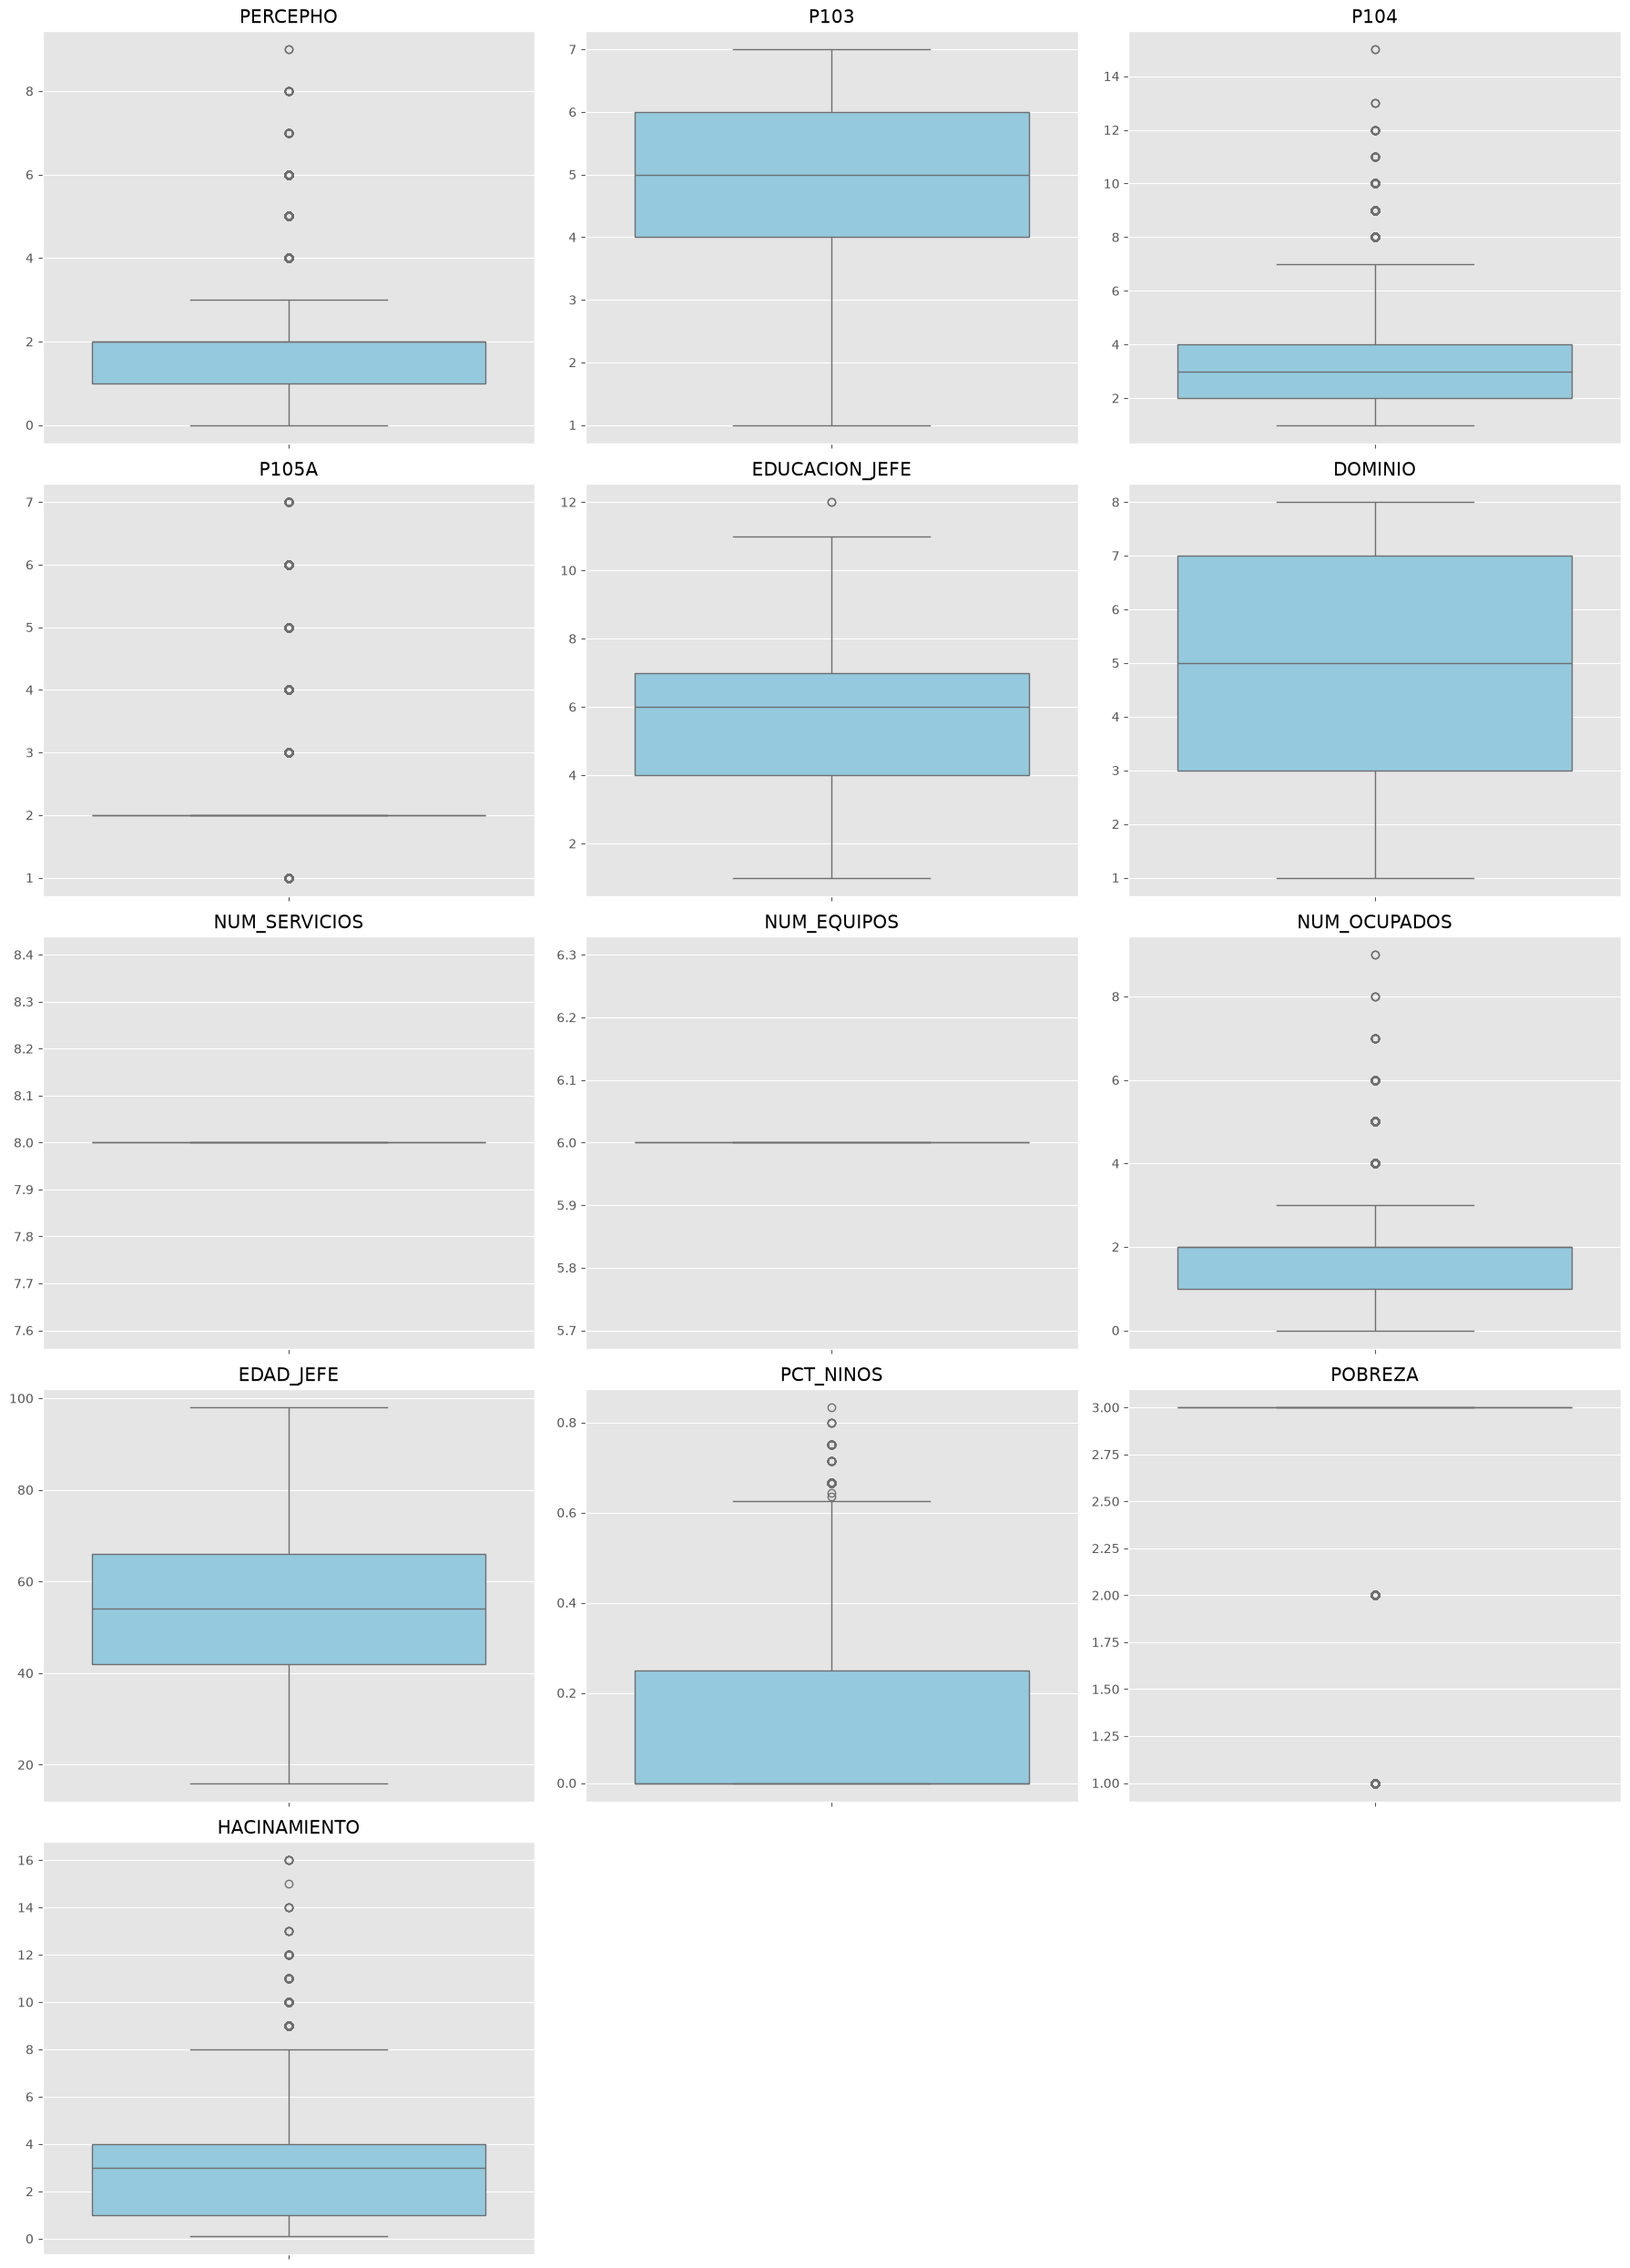

In [6]:
# ==========================================
# VISUALIZACIÓN DE OUTLIERS MEDIANTE BOXPLOTS
# ==========================================

import math

# Número de columnas por fila
columnas = 3
filas = math.ceil(len(df_numerico.columns) / columnas)

fig, axes = plt.subplots(filas, columnas, figsize=(18, 5 * filas))
axes = axes.flatten()

for i, columna in enumerate(df_numerico.columns):
    sns.boxplot(y=df_numerico[columna], ax=axes[i], color="skyblue")
    axes[i].set_title(columna)
    axes[i].set_ylabel("")

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# Guardar la figura
plt.savefig(
    "../figures/outliers_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
# ==========================================
# DETECCIÓN DE OUTLIERS MEDIANTE IQR
# ==========================================

resultados_iqr = []

for columna in df_numerico.columns:

    Q1 = df_numerico[columna].quantile(0.25)
    Q3 = df_numerico[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df_numerico[
        (df_numerico[columna] < limite_inferior) |
        (df_numerico[columna] > limite_superior)
    ]

    resultados_iqr.append({
        "Variable": columna,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Límite inferior": round(limite_inferior, 2),
        "Límite superior": round(limite_superior, 2),
        "Outliers": len(outliers)
    })

tabla_iqr = pd.DataFrame(resultados_iqr)

display(tabla_iqr)

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Outliers
0,PERCEPHO,1.0,2.00,1.00,-0.50,3.50,2535
1,P103,4.0,6.00,2.00,1.00,9.00,0
2,P104,2.0,4.00,2.00,-1.00,7.00,584
3,P105A,2.0,2.00,0.00,2.00,2.00,9451
4,EDUCACION_JEFE,4.0,7.00,3.00,-0.50,11.50,2
5,DOMINIO,3.0,7.00,4.00,-3.00,13.00,0
6,NUM_SERVICIOS,8.0,8.00,0.00,8.00,8.00,0
7,NUM_EQUIPOS,6.0,6.00,0.00,6.00,6.00,0
8,NUM_OCUPADOS,1.0,2.00,1.00,-0.50,3.50,1764
9,EDAD_JEFE,42.0,66.00,24.00,6.00,102.00,0


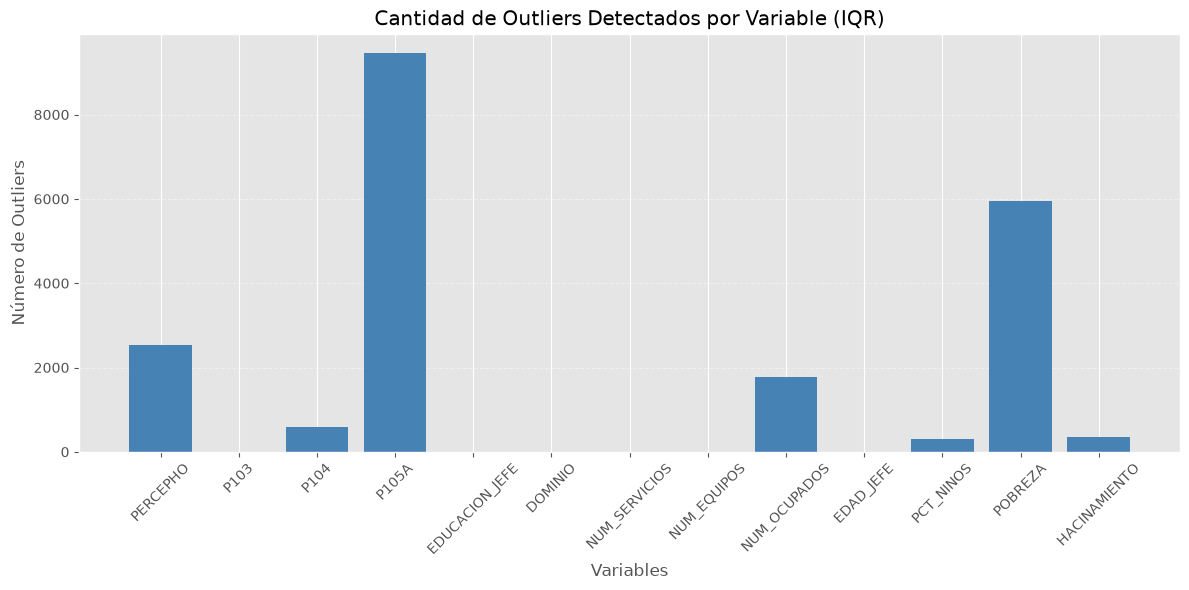

In [8]:
# ==========================================
# VISUALIZACIÓN DE OUTLIERS DETECTADOS (IQR)
# ==========================================

plt.figure(figsize=(12,6))

plt.bar(
    tabla_iqr["Variable"],
    tabla_iqr["Outliers"],
    color="steelblue"
)

plt.title("Cantidad de Outliers Detectados por Variable (IQR)")
plt.xlabel("Variables")
plt.ylabel("Número de Outliers")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# Guardar figura
plt.savefig(
    "../figures/outliers_iqr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
# ==========================================
# DETECCIÓN DE OUTLIERS MEDIANTE Z-SCORE
# ==========================================

from scipy.stats import zscore

# Calcular Z-Score
z_scores = np.abs(zscore(df_numerico))

# Convertir a DataFrame
z_scores = pd.DataFrame(
    z_scores,
    columns=df_numerico.columns
)

# Contar outliers por variable (|Z| > 3)
resultados_zscore = pd.DataFrame({
    "Variable": df_numerico.columns,
    "Outliers": (z_scores > 3).sum().values
})

print("✅ Outliers detectados mediante Z-Score")

display(resultados_zscore)

✅ Outliers detectados mediante Z-Score


C:\Users\JEFFERSON\AppData\Local\Temp\ipykernel_32608\1021538578.py:8: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = np.abs(zscore(df_numerico))


,Variable,Outliers
0,PERCEPHO,697
1,P103,0
2,P104,278
3,P105A,0
4,EDUCACION_JEFE,0
5,DOMINIO,0
6,NUM_SERVICIOS,0
7,NUM_EQUIPOS,0
8,NUM_OCUPADOS,425
9,EDAD_JEFE,0
